In [1]:
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from mpl_toolkits.mplot3d import Axes3D

from Robust_MOSP import Robust_MOSP
from utils.generate_graph import generate_graph

# incrementing node sizes twice the previous
NODE_SIZES = [4, 8, 16, 32, 64, 128, 256, 512, 1024]
EDGE_PROBS = [0.1, 0.2, 0.4, 0.6, 0.8, 1.0]  # edge probablity for nodes
REPEAT = 10  # repetation of 10

results = []
total_runs = len(NODE_SIZES) * len(EDGE_PROBS) * \
    REPEAT  # total number of running time

with tqdm(total=total_runs) as pbar:
    for n in NODE_SIZES:
        for p in EDGE_PROBS:
            for r in range(REPEAT):
                G = generate_graph(n, p)
                start = time.perf_counter()
                Robust_MOSP(G)  # running robust_mosp_update algo
                end = time.perf_counter()
                runtime = end - start  # runtime for running algo

                results.append({
                    "nodes": n,
                    "edge_prob": p,
                    "runtime": runtime
                })

                pbar.update(1)


100%|██████████| 540/540 [31:52<00:00,  3.54s/it] 


In [2]:
# DON'T RUN THIS AGAIN
df = pd.DataFrame(results)
df.to_csv("Robust_MOSP_results.csv", index=False)

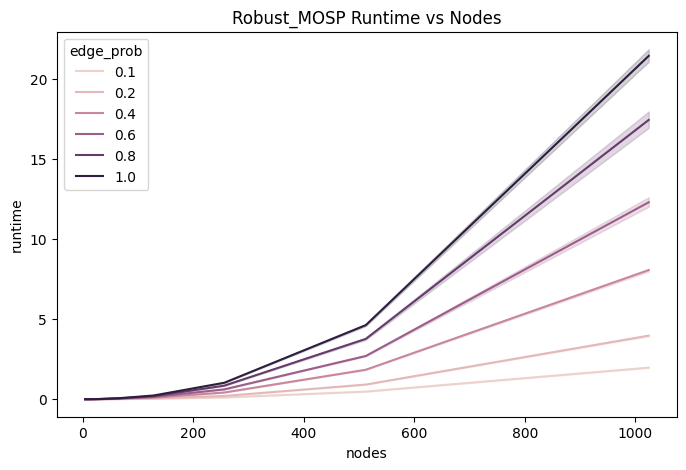

In [3]:
# plotting runtime vs nodes
plt.figure(figsize=(8, 5))

sns.lineplot(
    data=df,
    x="nodes",
    y="runtime",
    hue="edge_prob",
    estimator="mean"
)

plt.title("Robust_MOSP Runtime vs Nodes")
plt.show()

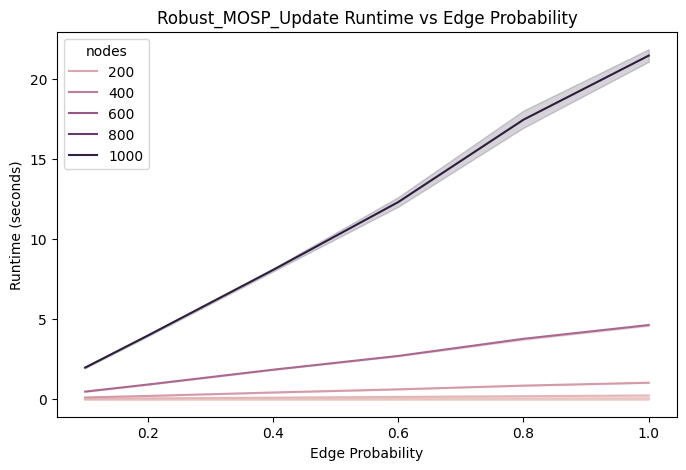

In [4]:
# Runtime vs Edge probablity
plt.figure(figsize=(8, 5))

sns.lineplot(data=df,
             x="edge_prob",
             y="runtime",
             hue="nodes",
             estimator="mean")

plt.title("Robust_MOSP_Update Runtime vs Edge Probability")
plt.xlabel("Edge Probability")
plt.ylabel("Runtime (seconds)")

plt.show()


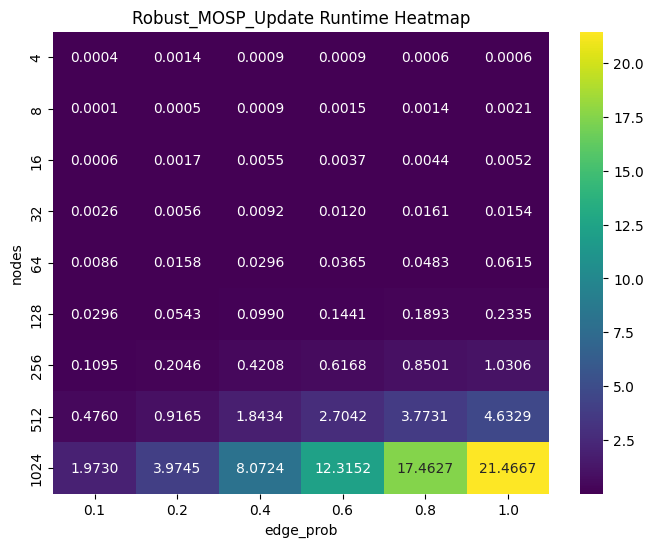

In [5]:
# nodes vs edge probablity
pivot = df.pivot_table(
    values="runtime",
    index="nodes",
    columns="edge_prob",
    aggfunc=np.mean
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    pivot,
    annot=True,
    fmt=".4f",
    cmap="viridis"
)

plt.title("Robust_MOSP_Update Runtime Heatmap")
plt.show()


In [1]:
# # 3D surface plot
# from mpl_toolkits.mplot3d import Axes3D

# nodes = pivot.index.values
# edge_probs = pivot.columns.values

# X, Y = np.meshgrid(edge_probs, nodes)
# Z = pivot.values

# fig = plt.figure(figsize=(10, 7))
# ax = fig.add_subplot(111, projection='3d')

# surface = ax.plot_surface(
#     X, Y, Z,
#     cmap='viridis',
#     edgecolor='k',
#     alpha=0.9
# )


# ax.set_xlabel("Edge Probability")
# ax.set_ylabel("Nodes")
# ax.set_zlabel("Runtime")
# fig.colorbar(surface, shrink=0.5, aspect=10)

# plt.show()

C:\Users\hp\AppData\Local\Temp\ipykernel_6700\3919877394.py:90: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


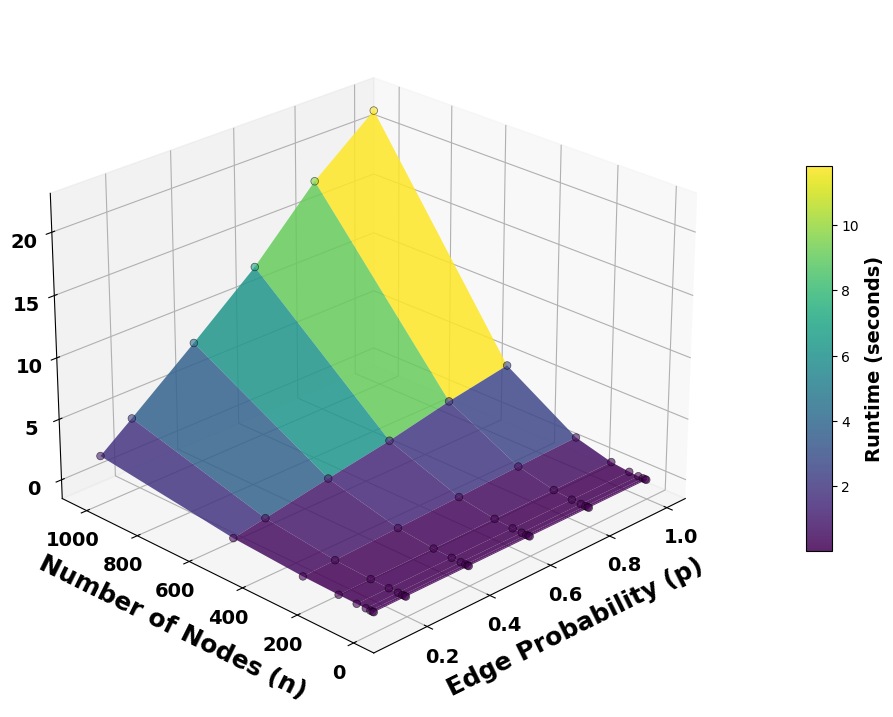


=== Robust_MOSP Runtime Analysis Summary ===

Runtime Statistics:
Minimum Runtime: 7.92e-05 seconds
Maximum Runtime: 2.27e+01 seconds
Mean Runtime: 1.55e+00 seconds

Runtimes by Number of Nodes:
            min        max       mean
nodes                                
4      0.000170   0.010518   0.000798
8      0.000079   0.006778   0.001090
16     0.000233   0.026395   0.003518
32     0.001495   0.026043   0.010152
64     0.007982   0.081992   0.033406
128    0.027982   0.251155   0.124973
256    0.106790   1.077467   0.538713
512    0.440303   4.839548   2.391027
1024   1.884118  22.650446  10.877422

Runtimes by Edge Probability:
                min        max      mean
edge_prob                               
0.1        0.000079   2.147175  0.288956
0.2        0.000088   4.123615  0.574991
0.4        0.000211   8.318576  1.164627
0.6        0.000520  13.205083  1.759432
0.8        0.000498  19.146340  2.482896
1.0        0.000537  22.650446  3.049831


In [1]:
# 3D Visualization: Runtime as a function of Edge Probability and Number of Nodes
# Suitable for research article

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Read the CSV file
df_results = pd.read_csv('Robust_MOSP_results.csv')

# Create pivot table for surface plot
pivot = df_results.pivot_table(
    values="runtime",
    index="nodes",
    columns="edge_prob",
    aggfunc=np.mean
)

nodes = pivot.index.values
edge_probs = pivot.columns.values

# Create meshgrid
X, Y = np.meshgrid(edge_probs, nodes)
Z = pivot.values

# Create 3D surface plot
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Plot surface with enhanced styling
surface = ax.plot_surface(
    X, Y, Z,
    cmap='viridis',
    edgecolor='none',
    alpha=0.85,
    linewidth=0,
    antialiased=True,
    rstride=1,
    cstride=1
)

# Add scatter points on the surface for emphasis
scatter = ax.scatter(
    X, Y, Z,
    c=Z,
    cmap='viridis',
    s=30,
    alpha=0.6,
    edgecolor='black',
    linewidth=0.5
)

# Set labels with proper font sizing
ax.set_xlabel('Edge Probability (p)', fontsize=18, labelpad=10, fontweight='heavy')
ax.set_ylabel('Number of Nodes (n)', fontsize=18, labelpad=10, fontweight='heavy')
ax.set_zlabel('Runtime (seconds)', fontsize=18, labelpad=15, fontweight='heavy')
# ax.set_title('Greedy_SOSP Runtime Analysis\n3D Surface Plot', 
#              fontsize=14, fontweight='bold', pad=20)

# Customize tick labels
ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y', labelsize=14)
ax.tick_params(axis='z', labelsize=14)

# Set tick label font weight to bold
for label in ax.get_xticklabels():
    label.set_weight('heavy')
for label in ax.get_yticklabels():
    label.set_weight('heavy')
for label in ax.get_zticklabels():
    label.set_weight('heavy')
    label.set_fontsize(14)





# Add colorbar
cbar = fig.colorbar(surface, shrink=0.5, aspect=15, pad=0.1)
cbar.set_label('Runtime (seconds)', fontsize=14, fontweight='bold')

# Set viewing angle for better visualization
ax.view_init(elev=25, azim=225)

# Add grid
ax.grid(True, alpha=0.3)

# Tight layout
plt.tight_layout()

# Save high-quality version for research article
plt.savefig('Robust_MOSP_3D_Runtime_Analysis.pdf', dpi=600, bbox_inches='tight')
plt.show()

# Print summary statistics
print("\n=== Robust_MOSP Runtime Analysis Summary ===")
print(f"\nRuntime Statistics:")
print(f"Minimum Runtime: {df_results['runtime'].min():.2e} seconds")
print(f"Maximum Runtime: {df_results['runtime'].max():.2e} seconds")
print(f"Mean Runtime: {df_results['runtime'].mean():.2e} seconds")
print(f"\nRuntimes by Number of Nodes:")
print(df_results.groupby('nodes')['runtime'].agg(['min', 'max', 'mean']))
print(f"\nRuntimes by Edge Probability:")
print(df_results.groupby('edge_prob')['runtime'].agg(['min', 'max', 'mean']))

**Combined Graph Plotting**

C:\Users\hp\AppData\Local\Temp\ipykernel_8816\3625246550.py:143: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(rect=[0, 0, 1, 0.94])


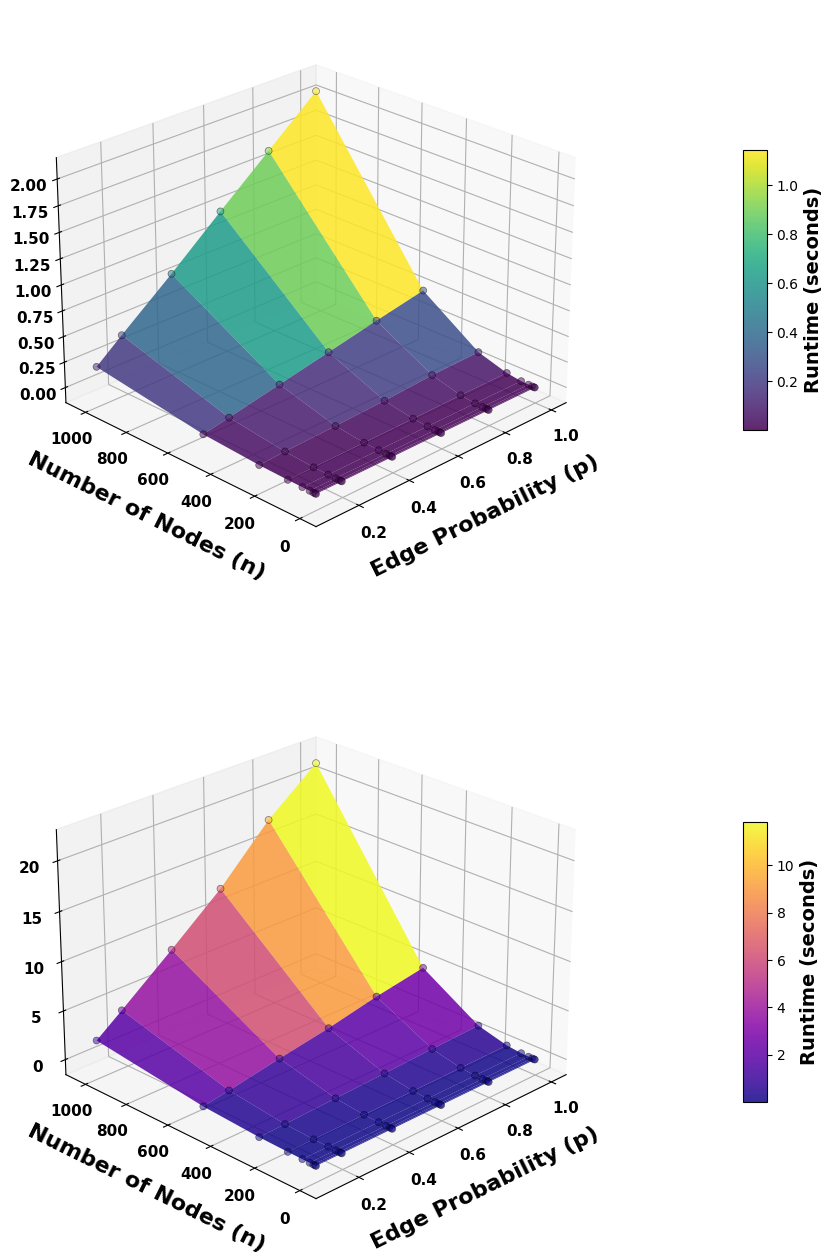


ALGORITHM RUNTIME COMPARISON (3D ANALYSIS)

--- GREEDY_SOSP ---
Minimum Runtime: 6.90e-06 seconds
Maximum Runtime: 2.15e+00 seconds
Mean Runtime: 1.55e-01 seconds

--- ROBUST_MOSP ---
Minimum Runtime: 7.92e-05 seconds
Maximum Runtime: 2.27e+01 seconds
Mean Runtime: 1.55e+00 seconds

--- COMPARISON ---
Robust_MOSP is 10.05x slower than Greedy_SOSP (on average)

Max Runtime Ratio: 10.54x


In [30]:
# Combined Horizontal 3D Plot: Greedy_SOSP (left) vs Robust_MOSP (right)
# Suitable for research paper with improved styling

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Read both CSV files
df_greedy = pd.read_csv('Greedy_SOSP_results.csv')
df_robust = pd.read_csv('Robust_MOSP_results.csv')

# Create pivot tables for both algorithms
pivot_greedy = df_greedy.pivot_table(
    values="runtime",
    index="nodes",
    columns="edge_prob",
    aggfunc=np.mean
)

pivot_robust = df_robust.pivot_table(
    values="runtime",
    index="nodes",
    columns="edge_prob",
    aggfunc=np.mean
)

# Extract data for meshgrid
nodes_greedy = pivot_greedy.index.values
edge_probs_greedy = pivot_greedy.columns.values
X_greedy, Y_greedy = np.meshgrid(edge_probs_greedy, nodes_greedy)
Z_greedy = pivot_greedy.values

nodes_robust = pivot_robust.index.values
edge_probs_robust = pivot_robust.columns.values
X_robust, Y_robust = np.meshgrid(edge_probs_robust, nodes_robust)
Z_robust = pivot_robust.values

# Create figure with 2 subplots arranged vertically
fig = plt.figure(figsize=(25, 16))

# ============ Greedy_SOSP (Top) ============
ax1 = fig.add_subplot(2, 1, 1, projection='3d')

surface1 = ax1.plot_surface(
    X_greedy, Y_greedy, Z_greedy,
    cmap='viridis',
    edgecolor='none',
    alpha=0.85,
    linewidth=0,
    antialiased=True,
    rstride=1,
    cstride=1
)

ax1.scatter(
    X_greedy, Y_greedy, Z_greedy,
    c=Z_greedy,
    cmap='viridis',
    s=25,
    alpha=0.5,
    edgecolor='black',
    linewidth=0.5
)

ax1.set_xlabel('Edge Probability (p)', fontsize=16, labelpad=10, fontweight='bold')
ax1.set_ylabel('Number of Nodes (n)', fontsize=16, labelpad=10, fontweight='bold')
ax1.set_zlabel('Runtime (seconds)', fontsize=16, labelpad=15, fontweight='bold')
# ax1.set_title('(a) Greedy_SOSP Runtime Analysis', fontsize=13, fontweight='bold', pad=15)
ax1.view_init(elev=25, azim=225)
# ax1.view_init(elev=90, azim=0)
ax1.grid(True, alpha=0.3)

# Customize tick labels for Greedy
ax1.tick_params(axis='x', labelsize=11)
ax1.tick_params(axis='y', labelsize=11)
ax1.tick_params(axis='z', labelsize=11)

for label in ax1.get_xticklabels():
    label.set_weight('bold')
for label in ax1.get_yticklabels():
    label.set_weight('bold')
for label in ax1.get_zticklabels():
    label.set_weight('bold')

# Add colorbar for Greedy_SOSP
cbar1 = fig.colorbar(surface1, ax=ax1, shrink=0.5, aspect=12, pad=0.08)
cbar1.set_label('Runtime (seconds)', fontsize=14, fontweight='bold')

# ============ Robust_MOSP (Bottom) ============
ax2 = fig.add_subplot(2, 1, 2, projection='3d')

surface2 = ax2.plot_surface(
    X_robust, Y_robust, Z_robust,
    cmap='plasma',
    edgecolor='none',
    alpha=0.85,
    linewidth=0,
    antialiased=True,
    rstride=1,
    cstride=1
)

ax2.scatter(
    X_robust, Y_robust, Z_robust,
    c=Z_robust,
    cmap='plasma',
    s=25,
    alpha=0.5,
    edgecolor='black',
    linewidth=0.5
)

ax2.set_xlabel('Edge Probability (p)', fontsize=16, labelpad=10, fontweight='bold')
ax2.set_ylabel('Number of Nodes (n)', fontsize=16, labelpad=10, fontweight='bold')
ax2.set_zlabel('Runtime (seconds)', fontsize=16, labelpad=15, fontweight='bold')
# ax2.set_title('(b) Robust_MOSP Runtime Analysis', fontsize=13, fontweight='bold', pad=15)
ax2.view_init(elev=25, azim=225)
# ax2.view_init(elev=90, azim=0)
ax2.grid(True, alpha=0.3)

# Customize tick labels for Robust
ax2.tick_params(axis='x', labelsize=11)
ax2.tick_params(axis='y', labelsize=11)
ax2.tick_params(axis='z', labelsize=11)

for label in ax2.get_xticklabels():
    label.set_weight('bold')
for label in ax2.get_yticklabels():
    label.set_weight('bold')
for label in ax2.get_zticklabels():
    label.set_weight('bold')

# Add colorbar for Robust_MOSP
cbar2 = fig.colorbar(surface2, ax=ax2, shrink=0.5, aspect=12, pad=0.08)
cbar2.set_label('Runtime (seconds)', fontsize=14, fontweight='bold')

# # Add main title
# fig.suptitle('Algorithm Runtime Comparison: 3D Surface Analysis\nRuntime vs Edge Probability and Number of Nodes',
#              fontsize=15, fontweight='bold', y=0.95)


plt.tight_layout(rect=[0, 0, 1, 0.94])

# Save high-quality version for research paper
plt.savefig('Greedy_SOSP_vs_Robust_MOSP_3D_Horizontal_Comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# Print comparison statistics
print("\n" + "="*70)
print("ALGORITHM RUNTIME COMPARISON (3D ANALYSIS)")
print("="*70)

print("\n--- GREEDY_SOSP ---")
print(f"Minimum Runtime: {df_greedy['runtime'].min():.2e} seconds")
print(f"Maximum Runtime: {df_greedy['runtime'].max():.2e} seconds")
print(f"Mean Runtime: {df_greedy['runtime'].mean():.2e} seconds")

print("\n--- ROBUST_MOSP ---")
print(f"Minimum Runtime: {df_robust['runtime'].min():.2e} seconds")
print(f"Maximum Runtime: {df_robust['runtime'].max():.2e} seconds")
print(f"Mean Runtime: {df_robust['runtime'].mean():.2e} seconds")

print("\n--- COMPARISON ---")
speedup = df_robust['runtime'].mean() / df_greedy['runtime'].mean()
print(f"Robust_MOSP is {speedup:.2f}x {'slower' if speedup > 1 else 'faster'} than Greedy_SOSP (on average)")
print(f"\nMax Runtime Ratio: {df_robust['runtime'].max() / df_greedy['runtime'].max():.2f}x")